In [2]:
import os
import sys
# add upper directory to path in order to import utilities and models
sys.path.append('../')

import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import torch
import pickle
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm import tqdm 

from ESN_utilities import *
from Plotting_utilities import * 
from ESN_models import *

# Helper function for visualization.
%matplotlib inline
# automatic reload of external definitions if changed during testing
%load_ext autoreload
%autoreload 2

# IGNORE WARNING MESSAGES on numpy and pytorch. These are due to the necessity to use numpy 2.4 in order to use the 
# latest version of the qiskit machine learning module. These warnings are not relevant for our purposes 
# with the exception of the conversion between pytorch tensors and numpy arrays, which in this case is achieved 
# by using a local patch.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### The Berkeley TAVG datasets.

Here we use as an example the task of forecasting the global average surface temperature (TAVG) using the `CQ-ESN` algorithm.

The TAVG dataset used in this notebook is a subset of the **global** average surface temperature dataset provided by the Berkeley Earth project. It contains monthly average temperatures from 1960 to 2020, measured in degrees Celsius. The original dataset is expanded to include **local** climate data from 18 countries in different continents.

While the dataset is multivaried (global + local, 19 variables), we focus on forecasting and plotting primarily the global average surface temperature (TAVG). When CQ-ESN is used ***autoregressively***, it forecasts all 19 variables in the **horizon** in order to roll forward by 1 timestep the **lag** of time used for prediction, although only the global average surface temperature (TAVG) is plotted.

In [3]:
# load countries data from folder data_countries
datasets_folder = os.listdir("../datasets")

# Read data/countries/combined_tavg_1960_to_2020_df.csv
combined_tavg_1960_to_2020_df = pd.read_csv('../datasets/combined_tavg_1960_to_2020_df.csv', index_col=0, parse_dates=True)
extended_combined_tavg_1960_to_2060_df = pd.read_csv('../datasets/extended_combined_tavg_1960_to_2060_df.csv', index_col=0, parse_dates=True)



In [4]:
combined_tavg_1960_to_2020_df.shape #, extended_combined_tavg_1960_to_2060_df.shape

(732, 21)

In [5]:
combined_tavg_1960_to_2020_df.head()

,Year,Month,global,argentina,australia,brazil,canada,china,egypt,germany,...,japan,mexico,russia,south-africa,saudi-arabia,spain,sudan,sweden,turkey,venezuela
Date,,,,,,,,,,,,,,,,,,,,,
1960-01-01,1960,1,0.081,0.987,0.570,-0.008,1.418,-0.175,0.429,0.454,...,-0.186,0.001,-1.576,-0.243,0.648,0.030,-0.312,-0.963,1.831,0.198
1960-02-01,1960,2,0.555,1.097,-0.379,-0.140,2.909,2.777,0.605,0.027,...,1.496,-1.466,0.164,0.267,1.268,0.695,0.769,-1.631,0.229,0.260
1960-03-01,1960,3,-1.074,0.040,-0.289,-0.311,-2.227,0.956,0.427,1.001,...,1.192,0.031,-2.132,0.096,-0.180,0.976,-0.688,0.969,-0.484,0.313
1960-04-01,1960,4,-0.279,0.215,-0.364,-0.264,-0.327,-0.972,0.600,0.139,...,-0.744,-0.222,-0.363,-0.746,0.385,0.836,0.693,0.744,-0.581,0.091
1960-05-01,1960,5,-0.502,-0.737,-2.010,-0.769,1.268,-0.772,0.159,0.825,...,-0.180,0.060,-0.822,-0.536,-0.069,1.301,-0.327,1.657,1.048,0.080


In [6]:
# extended_combined_tavg_1960_to_2060_df.head()

In [7]:
# read data from datasets/tavg_datasets.npz
tavg_datasets = np.load('../datasets/tavg_datasets.npz', allow_pickle=True)
tavg_datasets.files

['all_data',
 'train_data',
 'val_data',
 'all_data_scaled',
 'train_data_scaled',
 'val_data_scaled']

In [8]:
all_data = tavg_datasets['all_data']
print(len(all_data),all_data.shape,type(all_data))
train_data = tavg_datasets['train_data']
print(len(train_data),train_data.shape,type(train_data))
val_data = tavg_datasets['val_data']
print(len(val_data),val_data.shape,type(val_data))

732 (732, 19) <class 'numpy.ndarray'>
512 (512, 19) <class 'numpy.ndarray'>
220 (220, 19) <class 'numpy.ndarray'>


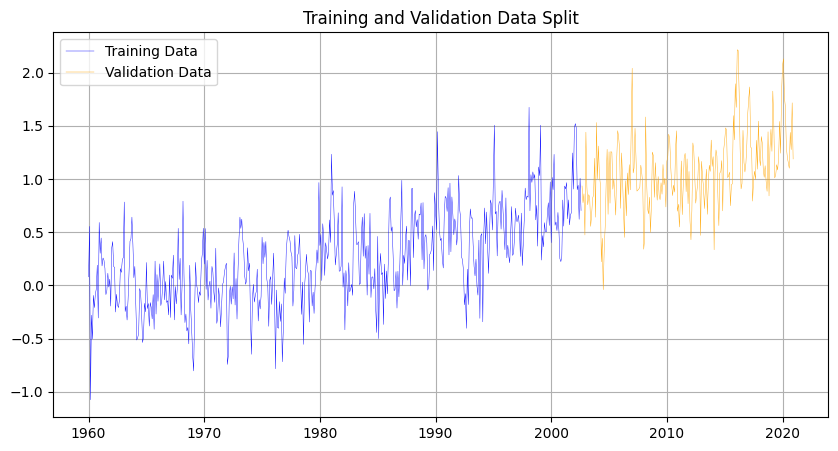

In [9]:
# Plot the training and validation data for the global temperature only
train_size = len(train_data)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(combined_tavg_1960_to_2020_df.index[:train_size], train_data[:, 0], label='Training Data', color='blue', linewidth=0.3)
ax.plot(combined_tavg_1960_to_2020_df.index[train_size:], val_data[:, 0], label='Validation Data', color='orange', linewidth=0.3)
ax.set_title('Training and Validation Data Split')
ax.legend()
ax.grid()
plt.show()

### Devices

In [10]:
# Check if CUDA is available (useful for NVIDIA GPUs, not applicable for Macs with AMD or INTEL GPUs or M chip)
cuda_available = torch.cuda.is_available()
print("CUDA available:", cuda_available)

# For Macs, checking for MPS availability (Metal Performance Shaders) for PyTorch versions that support it
mps_available = torch.backends.mps.is_available()
print("MPS available:", mps_available)
# Choose the hardware. For Macs, indicate whether new M chip is present
m_chip = False

# Define device
if cuda_available:
    for i in range(torch.cuda.device_count()):
        print(f"{i}: {torch.cuda.get_device_name(i)}")
    # Then, select the GPU device number, for example 0
    DEVICE = torch.device('cuda:0')
elif mps_available:
    if m_chip:
        DEVICE = torch.device('mps')
    else:
        DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu') 
print(DEVICE)


CUDA available: False
MPS available: False
cpu


#### `Dataset` and `DataLoader` classes for training and validation sets.

We use a **lag** of 12 months and an **horizon** of 1 month. The walk-forward moves the training window by 1 month at each step. The dataloader serves batches of 20 sequences during training. 

In [11]:
seq_length = 12 # default 12, which corresponds to one year of monthly data. This means that the model will use the past 12 months of data to predict the next month. We can experiment with different sequence lengths to see how it affects the performance of the model. Longer sequence lengths may capture more temporal dependencies but may also require more computational resources and may lead to overfitting if the training data is limited.
batch_size = 20 # default 20

# SHUFFLE BATCHES: For training, we typically want to shuffle the data to improve generalization. 
# However, for time series data, shuffling can break the temporal dependencies. 
# Therefore, we set shuffle=False for time series datasets to preserve the order of the sequences. 
# Shuffle, may be more appropriate for non-sequential data.

all_ds = TAVG_Dataset(all_data, seq_length=seq_length)
all_dl = DataLoader(all_ds, batch_size=batch_size, shuffle=True, drop_last=True)
train_ds = TAVG_Dataset(train_data, seq_length=seq_length)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_ds = TAVG_Dataset(val_data, seq_length=seq_length)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=True, drop_last=True)

# DO NOT SHUFFLE BATCHES: For time series data, we may not want to shuffle the data 
# to preserve the temporal dependencies.
# all_ds = TAVG_Dataset(all_data, seq_length=seq_length)
# all_dl = DataLoader(all_ds, batch_size=batch_size, shuffle=False, drop_last=True)
# train_ds = TAVG_Dataset(train_data, seq_length=seq_length)
# train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False, drop_last=True)
# val_ds = TAVG_Dataset(val_data, seq_length=seq_length)
# val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=True)

# TAVG_Dataset  
for i, batch in enumerate(train_dl):
    inputs, targets = batch
    print(inputs.shape, targets.shape)
    break

# Save datasets
torch.save(all_ds, '../datasets/all_ds.pt')
torch.save(train_ds, '../datasets/train_ds.pt')
torch.save(val_ds, '../datasets/val_ds.pt')

# Save data used to generate the datasets
np.savez('../datasets/esn_data.npz', all_data=all_data, train_data=train_data, val_data=val_data)

torch.Size([20, 12, 19]) torch.Size([20, 19])


Notice the difference in length between the original data and the datasets used for training and validation. Since each input sequence requires an *horizon* months of data, the training and validation datasets will be shorter than the original time series by the input sequence length.

In [12]:
all_len = len(all_data)
train_len = len(train_data)
val_len = len(val_data)

all_ds_len = len(all_ds)
train_ds_len = len(train_ds)
val_ds_len = len(val_ds)

print(f'All data length: {all_len}')
print(f'Train data length: {train_len}')
print(f'Val data length: {val_len}')

print(f'All dataset length: {all_ds_len}')
print(f'Train dataset length: {train_ds_len}')
print(f'Val dataset length: {val_ds_len}')

All data length: 732
Train data length: 512
Val data length: 220
All dataset length: 720
Train dataset length: 500
Val dataset length: 208


The following cells are provided for manual checking of the dataloader and the shapes of the input and output tensors. The input tensor has shape `(batch_size, lag, num_features)` and the output tensor has shape `(batch_size, horizon, num_features)`. In our case, `num_features` is 19 (global + local temperatures).

In [13]:
# train_ds[0]

In [14]:
# train_ds[1]

In [15]:
# train_ds[499]

In [16]:
# train_data[12]

In [17]:
# combined_tavg_1960_to_2020_df.iloc[12]

In [18]:
# train_data[511]

In [19]:
# combined_tavg_1960_to_2020_df.iloc[511]

In [20]:
# extended_combined_tavg_1960_to_2060_df.iloc[731]

#### Check for compatibility between torch tensors and numpy arrays in the training loop

In [21]:
import sys, torch, numpy as np
print(sys.executable)
print("torch:", torch.__version__)
print("numpy:", np.__version__)

/opt/anaconda3/envs/ibm_qml_311/bin/python
torch: 2.2.2
numpy: 2.3.5


Unfortunately, torch 2.2.2 requires numpy 1.26.4, which is not compatible with the version of numpy used in the IBM Machine Learning Module. To avoid issues with tensor operations and numpy array manipulations, we will implement a helper function `to_numpy_safe` that safely converts torch tensors to numpy arrays while leaving numpy arrays unchanged. This function will be used throughout the training loop to ensure compatibility between torch tensors and numpy arrays.

In [22]:
try:
    import torch
    _t = torch.tensor([1.0])
    _t.numpy()
    TORCH_NUMPY_WORKS = True
except RuntimeError:
    TORCH_NUMPY_WORKS = False

In [23]:
TORCH_NUMPY_WORKS

False

#### QC-ESN Training and Prediction Parameters

Examples and explanations of the key parameters used in CQ-ESN.

In [ ]:
# RANDOM_SEED = 1
# set_pytorch_seed(RANDOM_SEED)

# Choice of reservoir type: "WS" for Watts-Strogatz, "ER" for Erdos-Renyi, "BA" for Barabasi-Albert, "CU" for a custom reservoir with fixed weights.
reservoir_type = "CU" # "WS", "ER", "BA", "CU"
directed=True # whether the reservoir connections are directed or undirected (applicable for WS, ER, BA) 
w_range=(-1,1) # range for the non-zero weights in the reservoir matrix
keep_self_loops=True # whether to keep self-loops in the reservoir matrix 
distr="uniform" # distribution to sample the non-zero weights in the reservoir matrix ("uniform" or "normal")
er_p=0.02 # probability of edge creation for Erdos-Renyi reservoir
ba_m=1 # number of edges to attach to each new node in Barabasi-Albert reservoir
ws_k=3 # each node is connected to k nearest neighbors in ring topology for Watts-Strogatz reservoir
ws_beta=0.6 # rewiring probability for Watts-Strogatz reservoir
density=0.02 # density of the reservoir matrix
random_state=42 # random seed for reproducibility of the reservoir matrix generation
spectral_radius=0.95 # desired spectral radius of the reservoir matrix, which controls the echo state property and the memory capacity of the reservoir. Values close to 1 can lead to longer memory but also risk instability, while values much less than 1 can lead to shorter memory.

# Reservoir size (dimensions of the reservoir matrix)
reservoir_size = 50

# Sequence length (lag), batch size, no. of features per timestep 
seq_length = 12
batch_size = 20
input_size = 19

# Reservoir and states hyperparameters
complex_valued = True # whether to use complex-valued reservoir states and weights
center_states = True # whether to center the reservoir states by subtracting the mean
reduce_states_rank_svd = True # whether to perform dimensionality reduction of the states using SVD
scores_dim = 16 # target dimensionality of the states after SVD reduction, if reduce_states_rank_svd is True. If None, keep all dimensions.
reduce_states_rank_umap = False # whether to perform dimensionality reduction of the states using UMAP
umap_dist_matrix = 'L2' # method to calculate the distance matrix for UMAP dimensionality reduction ('L2', 'L1', 'cosine', 'mahalanobis', 'fubini-study')
umap_dim = 4 # target dimensionality of the states after UMAP reduction, if reduce_states_rank_umap is True. If None, keep all dimensions.
quantum_kernel_pca = False # whether to perform dimensionality reduction of the states using quantum kernel PCA before fitting the readout
qpca_dim = 4 # target dimensionality of the states after quantum kernel PCA reduction, if quantum_kernel_pca is True. If None, keep all dimensions.
add_bias = True # whether to add a bias term to the states before fitting the readout
add_complex_bias = True # whether to add a complex bias term (with both real and imaginary parts) to the states before fitting the readout
normalize_states = False # whether to normalize the states to unit norm before fitting the readout (useful for quantum kernel methods)
denormalize_preds = False # whether to multiply the predictions by the norm of the states to un-normalize them after prediction, if normalize_states is True. This is intuitively the same as bringing the kernel out of quantum state normalization and into the predictions.
leak_alpha = 0.4 # leak rate for the reservoir state update, between 0 and 1. Higher values mean the reservoir states are updated more with the new input and less with the previous states.

# Training parameters
use_einsum = True # whether to use einsum for the reservoir state update, which can be more efficient for large reservoirs and batch sizes
readout_method = 'kernel_ridge' # method to fit the readout layer ('ridge', 'kernel_ridge', 'quantum_kernel_ridge')
ridge_alpha = 1.0 # regularization strength for ridge regression, if readout_method is 'ridge'
kernel_ridge_kernel = 'linear' # kernel to use for kernel ridge regression (e.g., 'linear', 'rbf'), if readout_method is 'kernel_ridge'
kernel_ridge_alpha = 1.0 # regularization strength for kernel ridge regression, if readout_method is 'kernel_ridge'
kernel_ridge_kwargs = {} # additional keyword arguments for the kernel ridge regression model, if readout_method is 'kernel_ridge'
target_trials = 200 # number of trials with new reservoir randomizations to train and evaluate to get an average performance
select_random = False # whether to randomly select a subset of the states for training the readout. This can speed up training and reduce memory usage.
select_n_samples = 40  # number of random samples to select if select_random is True.
display_quantum_circuits = True # whether to display the quantum circuits used for the quantum kernel methods
discard_transients = 10 # number of batches of training data to discard as transients (fading memory) before fitting the readout.
silent = True # whether to suppress print statements during training and prediction

# Prediction parameters
scale_norm = False # whether to scale the predictions by the ratio of the mean norm of the training states to the mean norm of the test states.
tavg_index = extended_combined_tavg_1960_to_2060_df.index # time index for the tavg data, used for aligning predictions with the true values during evaluation and plotting

# Plotting parameters
train_len = train_len # number of time steps to use for training (the rest will be used for validation)
val_len = val_len # number of time steps to use for validation
 

#### Multiple runs training and forecasting in the training and validation set

### COMPLEX KERNEL RIDGE READOUT 

**Kernel ridge regression readout**. States are complex valued, kernel ridge regression. 

For the object generation, the key parameters are:

                                complex_valued=True
                                center_states=True
                                reduce_states_rank_svd=True
                                add_bias=True
                                complex_bias=True
                                normalize_states=False
                                denormalize_preds=False
                                quantum_kernel_pca=False
                                scores_dim=16 (state dimensions from svd reduction)

For training (carried out by the method "train_from_dataloader"), the key parameter is:

                                readout_method='kernel_ridge'
                                kernel_ridge_kernel='linear'


In [25]:
attempt_number = 0
total_attempts = 200

# No need to run non updating predicitions
do_nar_nup_predictions = False
do_nar_predictions = True
do_ar_predictions = True
display_quantum_circuits = False

esn_models = []
all_nar_nup_preds_all_trials = []
all_nar_preds_all_trials = []
all_ar_preds_all_trials = []

# record execution time of the while loop
start_time = time.time()    

with tqdm(total=total_attempts, desc="ESN Trials") as pbar:
        while attempt_number < total_attempts:
                attempt_number += 1

                reservoir_seed = np.random.randint(0, 10000)

                if attempt_number == 1:
                        reservoir_analysis = True
                else:
                        reservoir_analysis = False

                print(f'\nProcessing ESN model {attempt_number}/{total_attempts}')                                 

                esn = CQ_ESN(input_size, seq_length, reservoir_size=50,
                                reservoir_type="CU",  
                                directed=True, w_range=(-1,1), keep_self_loops=True, distr="uniform",
                                er_p=0.02, ba_m=1, ws_k=3, ws_beta=0.6,
                                density=0.02, random_state=reservoir_seed, spectral_radius=0.95, # default 0.95 --- IGNORE ---
                                leak_alpha=0.5,  
                                ridge_alpha=1.0, # default 1.0e-6 --- IGNORE ---
                                kernel_ridge_alpha=1.0,
                                complex_valued=True,
                                center_states=True,
                                reduce_states_rank_svd=True,
                                reduce_states_rank_umap=False,
                                umap_dist_matrix='L2',
                                add_bias=True,
                                complex_bias=True,
                                # Here we set normalization and denormalization to False                                
                                normalize_states=False,
                                denormalize_preds=False,
                                quantum_kernel_pca=False,
                                scale_norm = False,
                                scores_dim=16,
                                qpca_dim=4, 
                                umap_dim=4,
                                use_einsum=True,  
                                discard_transients=0,
                                select_random=False, 
                                select_n_samples=40, 
                                silent=True, 
                                reservoir_analysis=reservoir_analysis,
                                torch_numpy_works=TORCH_NUMPY_WORKS)

                # Training
                esn.train_from_dataloader(train_dl,
                                          ridge_alpha=10.0,
                                          leak_alpha=0.5,
                                          use_einsum=True,
                                          readout_method='kernel_ridge',
                                          kernel_ridge_kernel='linear',
                                          kernel_ridge_alpha=10.0,
                                          kernel_ridge_kwargs={},
                                          quantum_kernel_kwargs={"use_entanglement_feature_map": False,
                                                                 "entangling_reps": 2,
                                                                 "entangling_gate": "cz",
                                                                #  optional custom topology:
                                                                #  "entangling_pairs": [(0,1), (1,2), (0,2)]
                                                                 },
                                          discard_transients=0,
                                          )                                                 
                
                # esn_models.append(esn)

                # make deep copies of trained esn for non-autoregressive and autoregressive predictions, 
                # since the states will be updated during prediction and we want to keep the original 
                # trained esn unchanged for fair comparison between the two types of predictions.            
                                
                # Here we use the dataset instead of the loader 
                # to have access to the individual sequences for autoregressive prediction
                # 
 
#################### PREDICTIONS LEAK RATE #################################################################

                prediction_leak_alpha = 0.5
                     
#################### NON AUTOREGRESSIVE NON-UPDATING PREDICTIONS ###########################################
                if do_nar_nup_predictions:
                        nar_nup_esn = copy.deepcopy(esn)
                        data_np = all_data
                        data_ds = all_ds               
                        start_point = 0
                        data_range = all_len - seq_length        
                        end_point = data_range
                        true_data = data_np[seq_length:all_len]
                        data_len = data_range
                        plot_params = {'q1':25, 'q3':75, 'y_lims':(-1.0, 1.8), 'box_x':0.71, 'box_y':0.40}

                        # prediction_leak_alpha = 0.5
                        use_training_states = True
                        update_training_states = False
                        all_nar_nup_preds = []

                        for i in range(data_range):
                                print(f'non_AR prediction step {i+1}/{data_range}', end='\r')
                                # Here we use the pytorch dataset
                                x,y = data_ds[i]                        
                                nar_nup_preds, states = nar_nup_esn.predict(x.unsqueeze(0), 
                                                leak_alpha=leak_alpha, states=None, 
                                                use_training_states=use_training_states, # default True
                                                use_einsum=use_einsum, 
                                                update_training_states=update_training_states)                                                               
                                all_nar_nup_preds.append(nar_nup_preds[0][0].item())

                        all_nar_nup_preds_all_trials.append(all_nar_nup_preds)                                             
                
#################### NON AUTOREGRESSIVE PREDICTIONS ########################################################
                if do_nar_predictions:
                        nar_esn = copy.deepcopy(esn)
                        data_np = all_data
                        data_ds = all_ds               
                        start_point = 0
                        data_range = all_len - seq_length        
                        end_point = data_range
                        true_data = data_np[seq_length:all_len]
                        data_len = data_range
                        plot_params = {'q1':25, 'q3':75, 'y_lims':(-1.0, 1.8), 'box_x':0.71, 'box_y':0.40}

                        # prediction_leak_alpha = 0.5
                        use_training_states = True
                        update_training_states = True
                        all_nar_preds = []

                        for i in range(data_range):
                                print(f'non_AR prediction step {i+1}/{data_range}', end='\r')
                                # Here we use the pytorch dataset
                                x,y = data_ds[i]                        
                                nar_preds, states = nar_esn.predict(x.unsqueeze(0), 
                                                leak_alpha=leak_alpha, states=None, 
                                                use_training_states=use_training_states, # default True
                                                use_einsum=use_einsum, 
                                                update_training_states=update_training_states)                                                               
                                all_nar_preds.append(nar_preds[0][0].item())

                        all_nar_preds_all_trials.append(all_nar_preds)                                             
                
#################### AUTOREGRESSIVE PREDICTIONS ############################################################
                if do_ar_predictions:
                        ar_esn = copy.deepcopy(esn)
                        data_np = val_data
                        data_ds = all_ds
                        start_point = train_len
                        data_range=val_len
                        end_point = start_point + data_range
                        true_data = data_np
                        data_len = len(data_np)

                        # prediction_leak_alpha = 0.5
                        use_training_states = True
                        update_training_states = True        
                        all_ar_preds = []

                        x, y = data_ds[start_point]
                        # print(f'Initial input x,y shape: {x.shape}, {y.shape}')
                                        
                        for i in range(data_range):                                        
                                print(f'AR prediction step {i+1}/{data_range}', end='\r')
                                ar_preds, states = ar_esn.predict(x.unsqueeze(0), 
                                                leak_alpha=prediction_leak_alpha, states=None, 
                                                use_training_states=use_training_states, # default True
                                                use_einsum=use_einsum, 
                                                update_training_states=update_training_states) # default True                                                              
                                        
                                all_ar_preds.append(ar_preds[0][0].item())

                                if TORCH_NUMPY_WORKS:
                                        x = torch.cat((x[1:], torch.from_numpy(ar_preds)), dim=0)
                                else:                                        
                                        ar_preds_t = torch.tensor(ar_preds, device=x.device, dtype=x.dtype)
                                        x = torch.cat((x[1:], ar_preds_t), dim=0)      

                        # append predictions for this model to the list of predictions for all models
                        all_ar_preds_all_trials.append(all_ar_preds)              

################################################################################################################
                
                pbar.update(1)
                pbar.set_postfix({"attempts": total_attempts})

        ridge_regr_all_ar_preds_all_trials = np.array(all_ar_preds_all_trials)
        ridge_regr_all_nar_preds_all_trials = np.array(all_nar_preds_all_trials)
        ridge_regr_all_nar_nup_preds_all_trials = np.array(all_nar_nup_preds_all_trials)         

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total time for {target_trials} trials: {elapsed_time/60:.2f} minutes")

if display_quantum_circuits:
        feature_dim = esn.scores_dim
        n_qubits = int(np.log2(esn.scores_dim))
        entangler = esn.entangler if hasattr(esn, 'entangler') else None 

        feature_circ, overlap_circ = esn._visualize_feature_map_and_overlap(n_qubits, feature_dim, entangler=entangler, reps=6, output="mpl", style=None, example_state=None)       

        feature_map_fig = feature_circ.decompose(reps=6).draw(output="mpl")        
        plt.title("Feature Map Circuit")
        plt.show()

        overlap_fig = overlap_circ.decompose(reps=6).draw(output="mpl")        
        plt.title("Overlap Circuit")
        plt.show()
        

ESN Trials:   0%|          | 0/200 [00:00<?, ?it/s]


Processing ESN model 1/200
Reservoir analysis: {'graph_arch': 'CU', 'graph_type': 'directed', 'asym_ratio': 0.9795918367346939, 'n_nodes': 50, 'n_edges': 48, 'density': 0.019591836734693877}


ESN Trials:   0%|          | 1/200 [00:02<07:00,  2.11s/it, attempts=200]

AR prediction step 220/220
Processing ESN model 2/200


ESN Trials:   1%|          | 2/200 [00:03<05:52,  1.78s/it, attempts=200]

...

AR prediction step 220/220
Processing ESN model 199/200


ESN Trials: 100%|█████████▉| 199/200 [06:02<00:01,  1.61s/it, attempts=200]

AR prediction step 220/220
Processing ESN model 200/200


ESN Trials: 100%|██████████| 200/200 [06:04<00:00,  1.82s/it, attempts=200]

Total time for 200 trials: 6.08 minutes


##### Plot ESN reservoir features

The last trial esn is used here as an example to visualize the reservoir features.

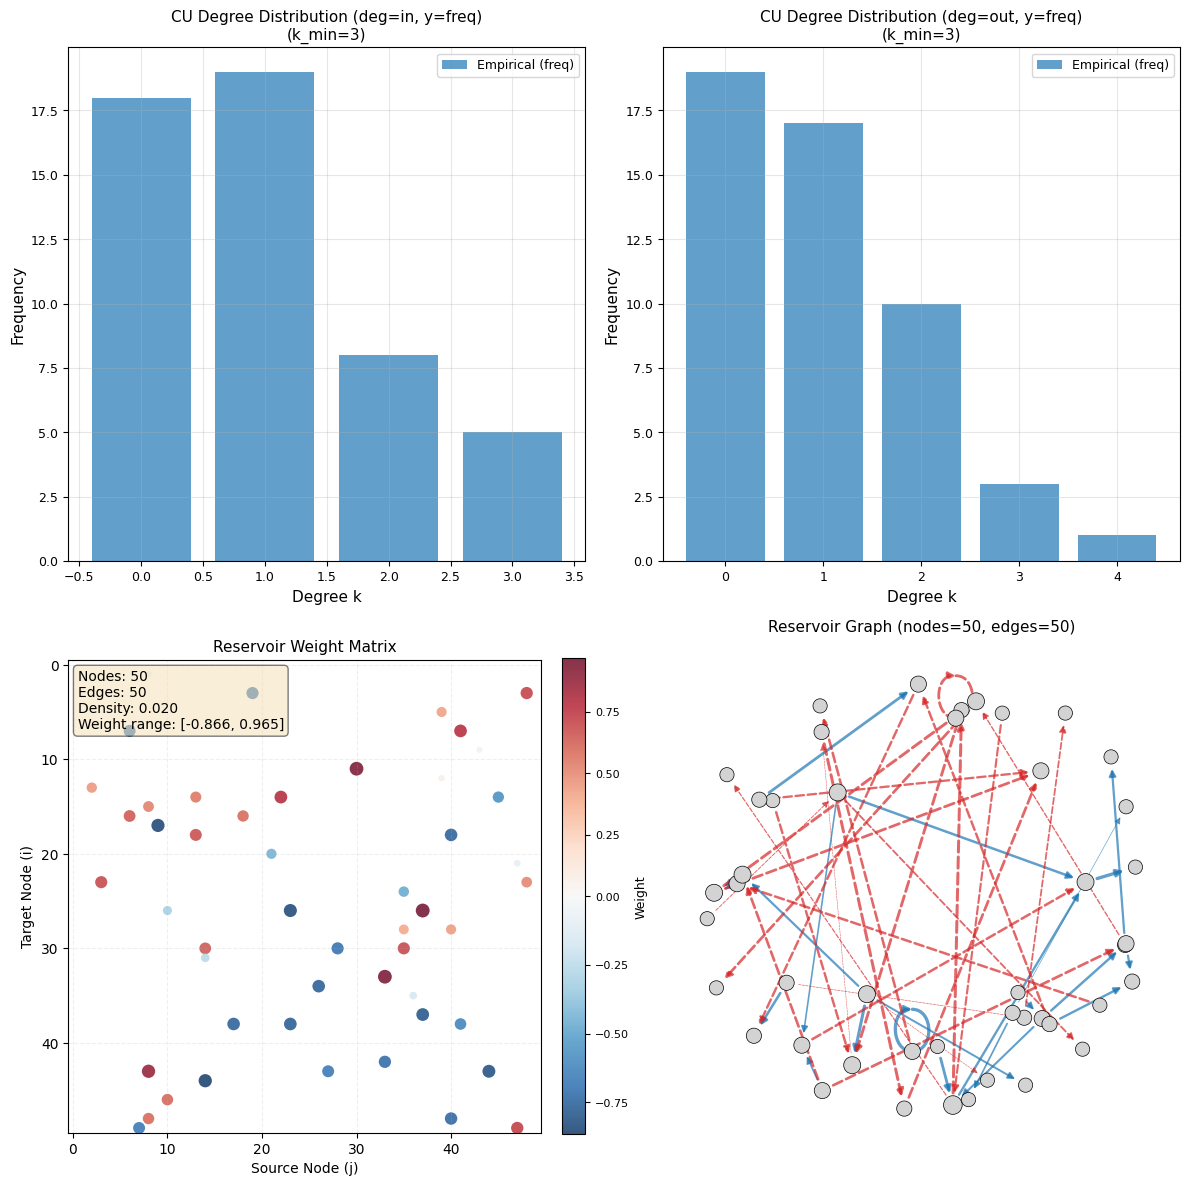

In [26]:
# plot reservoir matrix degree distribution
from ESN_utilities import plot_degree_distribution_with_powerlaw
from ESN_utilities import plot_reservoir_matrix, plot_esn_reservoir

# convert esn.W_res to real values by taking absolute value and giving it the sign of the real part
W_res = np.abs(esn.W_res) * np.sign(np.real(esn.W_res))

fig, ax = plt.subplots(2,2,figsize=(12,12))
reservoir_type = esn.reservoir_type
plot_degree_distribution_with_powerlaw(W_res, 
                                       res_type=reservoir_type, 
                                       plot_mode="linear",
                                       show_fit=False,
                                       degree_type="in",
                                       y_stat="freq",
                                       plot_kind="bar",
                                       fontsize=11, 
                                       ax=ax[0,0])

plot_degree_distribution_with_powerlaw(W_res, 
                                       res_type=reservoir_type, 
                                       plot_mode="linear",
                                       show_fit=False,
                                       degree_type="out",
                                       y_stat="freq",
                                       plot_kind="bar",
                                       fontsize=11, 
                                       ax=ax[0,1])

plot_reservoir_matrix(W_res, tol=1e-8, dot_size_scale=100,fig=fig, ax=ax[1,0], title="Reservoir Weight Matrix")

_ = plot_esn_reservoir(W_res, tol=1e-8, figsize=(7,7),node_size_base=90,layout="spring", with_labels=False, ax=ax[1,1])

plt.tight_layout()
plt.show()

#### NON-AUTOREGRESSIVE predictions in the training and validation sets WITHOUT updating the training states at each time step. 

In [27]:
if do_nar_nup_predictions:
        ################# Non-Autoregressive Non-Updating Training + Validation set range ###################################
        start_point = seq_length
        data_range = all_len - seq_length
        end_point = start_point + data_range
        true_data = all_data[seq_length:all_len] # = plot_all_data = all_data[seq_length:all_len]
        data_len = all_len - seq_length # plot_all_len = all_len - seq_length
        plot_params = {'q1':25, 'q3':75, 'y_lims':(-1.0, 1.8), 'box_x':0.70, 'box_y':0.40}
        model = (f"{esn.reservoir_type} {esn.reservoir_size} - ridge regr.")
        tavg_index = extended_combined_tavg_1960_to_2060_df.index
        index = tavg_index[start_point:end_point] # plot_all_tavg_index = plot_all_tavg_index[:plot_all_len]
        marker_location = tavg_index[train_len ]  # time corresponding to the last point of the training set
        titlestr = (f"Non-autoregressive Non-Updating Predictions: Train + Val sets, Marker: Train-Val Split")
        ######################################################################################################################

        q1, q3 = plot_params['q1'], plot_params['q3']
        y_lims = plot_params['y_lims']
        box_x, box_y = plot_params['box_x'], plot_params['box_y']

        nrmse_range, psd_nrmse_range, nrmse_std, psd_nrmse_std, \
        mae_, smape_, preds_iqr_area, preds_min_max_area, figure, ax = \
        plot_predictions_with_median_iqr(ridge_regr_all_nar_nup_preds_all_trials[:,:data_range], true_data=true_data, 
                                        data_len=data_len, tavg_index=index, model=model, 
                                        marker=marker_location, titlestr=titlestr, q1=q1, q3=q3, y_lims=y_lims, 
                                        box_x=box_x, box_y=box_y, show_plot=True)

        ridge_regr_nar_nup_train_val_metrics = {
                'data_len': data_len,
                'nrmse_range': nrmse_range,
                'psd_nrmse_range': psd_nrmse_range,
                'nrmse_std': nrmse_std,
                'psd_nrmse_std': psd_nrmse_std,
                'mae': mae_,
                'smape': smape_,
                'preds_iqr_area': preds_iqr_area,
                'preds_min_max_area': preds_min_max_area,
                'total_attempts': total_attempts,
                'run_time_minutes': elapsed_time/60,
        }


Note how predictions are reasonably accurate only around the final part of the training set and the beginning of the validation set, where the input values are similar to those used to finalize the model (arguably this occurs toward the end of the training set). Since there is no updating of the training states the model behaves similarly in the entire range of data, producing predictions that are close to the data mean.

#### NON-AUTOREGRESSIVE predictions in the training and validation sets WITH updating of the training states at each time step. 

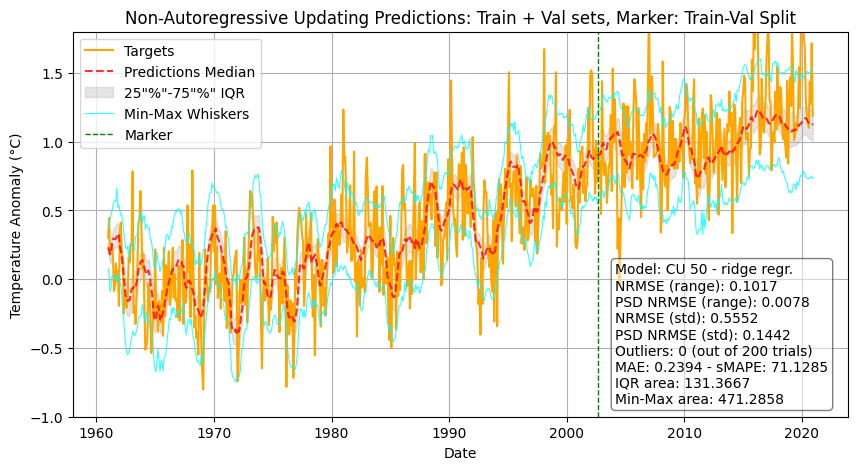

In [28]:
if do_nar_predictions:
        ################# Non-Autoregressive Training + Validation set range ####################################################
        start_point = seq_length
        data_range = all_len - seq_length
        end_point = start_point + data_range
        true_data = all_data[seq_length:all_len] # = plot_all_data = all_data[seq_length:all_len]
        data_len = all_len - seq_length # plot_all_len = all_len - seq_length
        plot_params = {'q1':25, 'q3':75, 'y_lims':(-1.0, 1.8), 'box_x':0.70, 'box_y':0.40}
        model = (f"{esn.reservoir_type} {esn.reservoir_size} - ridge regr.")
        tavg_index = extended_combined_tavg_1960_to_2060_df.index
        index = tavg_index[start_point:end_point] # plot_all_tavg_index = plot_all_tavg_index[:plot_all_len]
        marker_location = tavg_index[train_len ]  # time corresponding to the last point of the training set
        titlestr = (f"Non-Autoregressive Updating Predictions: Train + Val sets, Marker: Train-Val Split")
        ####################################################################################################

        q1, q3 = plot_params['q1'], plot_params['q3']
        y_lims = plot_params['y_lims']
        box_x, box_y = plot_params['box_x'], plot_params['box_y']

        nrmse_range, psd_nrmse_range, nrmse_std, psd_nrmse_std, \
        mae_, smape_, preds_iqr_area, preds_min_max_area, figure, ax = \
        plot_predictions_with_median_iqr(ridge_regr_all_nar_preds_all_trials[:,:data_range], true_data=true_data, 
                                        data_len=data_len, tavg_index=index, model=model, 
                                        marker=marker_location, titlestr=titlestr, q1=q1, q3=q3, y_lims=y_lims, 
                                        box_x=box_x, box_y=box_y, show_plot=True)

        ridge_regr_nar_train_val_metrics = {
                'data_len': data_len,
                'nrmse_range': nrmse_range,
                'psd_nrmse_range': psd_nrmse_range,
                'nrmse_std': nrmse_std,
                'psd_nrmse_std': psd_nrmse_std,
                'mae': mae_,
                'smape': smape_,
                'preds_iqr_area': preds_iqr_area,
                'preds_min_max_area': preds_min_max_area,
                'total_attempts': total_attempts,
                'run_time_minutes': elapsed_time/60,
        }


Note how predictions are now much more accurate throughout the training set. Accuracy remains approximately the same in the validation set, because training states update during predictions roll-over generates at the end of the training set states similar to the original training states. It is possible to modify this behavior by using a different *leak rate* during training and prediction. 

#### NON-AUTOREGRESSIVE predictions in the training set WITH updating of the training states at each time step. 

This is just a zoomed-in version of the previous plot, to better visualize the predictions in the training set, and provide better metrics for just this part of the data. 

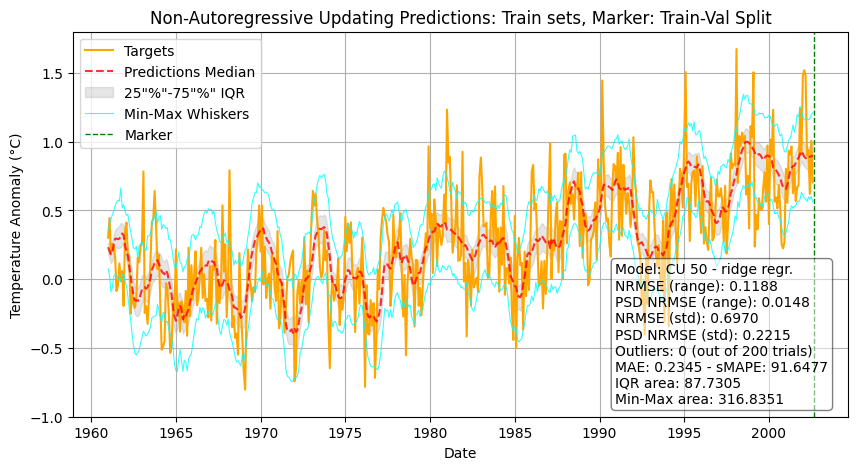

In [29]:
if do_nar_predictions:
        ################# Non-Autoregressive Training set range ###############################################################
        start_point = seq_length
        data_range = train_len - seq_length
        end_point = start_point + data_range
        true_data = train_data[seq_length:train_len] # = plot_train_data = train_data[seq_length:train_len]
        data_len = train_len - seq_length # plot_train_len = train_len - seq_length
        plot_params = {'q1':25, 'q3':75, 'y_lims':(-1.0, 1.8), 'box_x':0.70, 'box_y':0.40}
        model = (f"{esn.reservoir_type} {esn.reservoir_size} - ridge regr.")
        tavg_index = extended_combined_tavg_1960_to_2060_df.index
        index = tavg_index[start_point:end_point]
        marker_location = tavg_index[train_len ] 
        titlestr = (f"Non-Autoregressive Updating Predictions: Train sets, Marker: Train-Val Split")
        #######################################################################################################################

        q1, q3 = plot_params['q1'], plot_params['q3']
        y_lims = plot_params['y_lims']
        box_x, box_y = plot_params['box_x'], plot_params['box_y']

        nrmse_range, psd_nrmse_range, nrmse_std, psd_nrmse_std, \
        mae_, smape_, preds_iqr_area, preds_min_max_area, figure, ax = \
        plot_predictions_with_median_iqr(ridge_regr_all_nar_preds_all_trials[:,:data_range], true_data=true_data, 
                                        data_len=data_len, tavg_index=index, model=model, 
                                        marker=marker_location, titlestr=titlestr, q1=q1, q3=q3, y_lims=y_lims, 
                                        box_x=box_x, box_y=box_y, show_plot=True)

        ridge_regr_nar_train_metrics = {
                'data_len': data_len,
                'nrmse_range': nrmse_range,
                'psd_nrmse_range': psd_nrmse_range,
                'nrmse_std': nrmse_std,
                'psd_nrmse_std': psd_nrmse_std,
                'mae': mae_,
                'smape': smape_,
                'preds_iqr_area': preds_iqr_area,
                'preds_min_max_area': preds_min_max_area,
                'total_attempts': total_attempts,
                'run_time_minutes': elapsed_time/60,
        }


#### NON-AUTOREGRESSIVE predictions in the validation set WITH updating of the training states at each time step. 

This is just a zoomed-in version of the previous plot, to better visualize the predictions in the validation set, and provide better metrics for just this part of the data. 

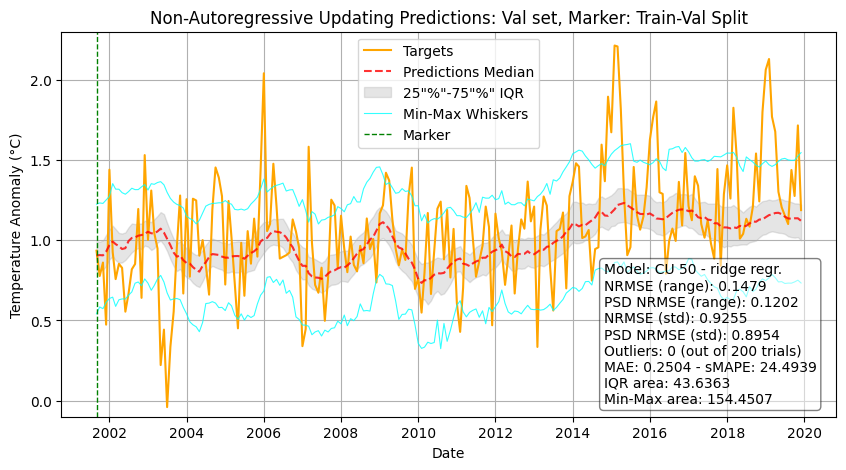

In [30]:
if do_nar_predictions:
        ################# Non-Autoregressive Validation set range ###############################################################
        data_np = val_data
        data_ds = all_ds
        start_point = train_len - seq_length  # data_range=val_len+(40*12) to predict beyond the validation set
        data_range=val_len
        end_point = start_point + data_range
        true_data = data_np
        data_len = len(data_np)
        plot_params = {'q1':25, 'q3':75, 'y_lims':(-0.1, 2.3), 'box_x':0.70, 'box_y':0.40}
        model = (f"{esn.reservoir_type} {esn.reservoir_size} - ridge regr.")
        tavg_index = extended_combined_tavg_1960_to_2060_df.index
        index = tavg_index[start_point:end_point]
        marker_location = tavg_index[train_len - seq_length]  # time corresponding to the last point of the training set
        titlestr = (f"Non-Autoregressive Updating Predictions: Val set, Marker: Train-Val Split") 
        ##########################################################################################################################

        q1, q3 = plot_params['q1'], plot_params['q3']
        y_lims = plot_params['y_lims']
        box_x, box_y = plot_params['box_x'], plot_params['box_y']

        nrmse_range, psd_nrmse_range, nrmse_std, psd_nrmse_std, \
        mae_, smape_, preds_iqr_area, preds_min_max_area, figure, ax = \
        plot_predictions_with_median_iqr(ridge_regr_all_nar_preds_all_trials[:,start_point:], true_data=true_data, 
                                        data_len=data_len, tavg_index=index, model=model, 
                                        marker=marker_location, titlestr=titlestr, q1=q1, q3=q3, y_lims=y_lims, 
                                        box_x=box_x, box_y=box_y, show_plot=True)

        ridge_regr_nar_val_metrics = {
                'data_len': data_len,
                'nrmse_range': nrmse_range,
                'psd_nrmse_range': psd_nrmse_range,
                'nrmse_std': nrmse_std,
                'psd_nrmse_std': psd_nrmse_std,
                'mae': mae_,
                'smape': smape_,
                'preds_iqr_area': preds_iqr_area,
                'preds_min_max_area': preds_min_max_area,
                'total_attempts': total_attempts,
                'run_time_minutes': elapsed_time/60,
        }



#### AUTOREGRESSIVE predictions in the validation set WITH updating of the training states at each time step.  

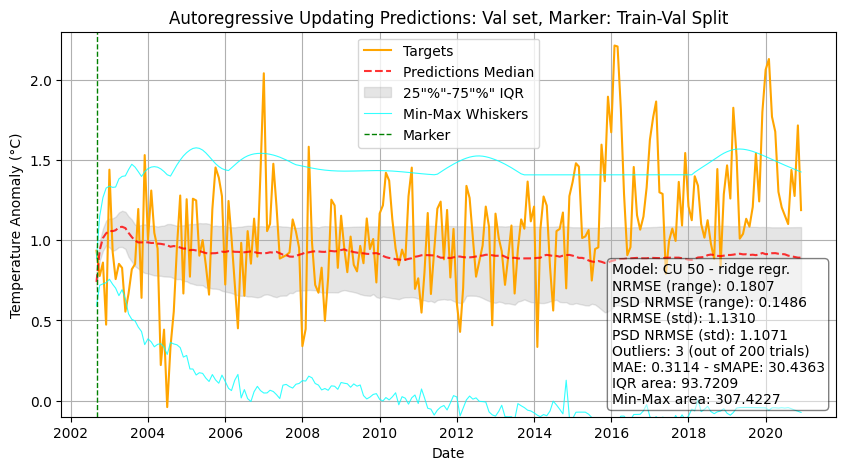

In [31]:
if do_ar_predictions:
        ################# Autoregressive Validation set range #####################################################################
        data_np = val_data
        data_ds = all_ds
        start_point = train_len # data_range=val_len+(40*12) to predict beyond the validation set
        data_range=val_len
        end_point = start_point + data_range
        true_data = data_np
        data_len = len(data_np)
        plot_params = {'q1':25, 'q3':75, 'y_lims':(-0.1, 2.3), 'box_x':0.71, 'box_y':0.40}
        model = (f"{esn.reservoir_type} {esn.reservoir_size} - ridge regr.")
        tavg_index = extended_combined_tavg_1960_to_2060_df.index
        index = tavg_index[start_point:end_point]
        marker_location = tavg_index[train_len]  # time corresponding to the last point of the training set
        titlestr = (f"Autoregressive Updating Predictions: Val set, Marker: Train-Val Split") 
        ############################################################################################################################

        q1, q3 = plot_params['q1'], plot_params['q3']
        y_lims = plot_params['y_lims']
        box_x, box_y = plot_params['box_x'], plot_params['box_y']

        nrmse_range, psd_nrmse_range, nrmse_std, psd_nrmse_std, \
        mae_, smape_, preds_iqr_area, preds_min_max_area, figure, ax = \
        plot_predictions_with_median_iqr(ridge_regr_all_ar_preds_all_trials, true_data=true_data, data_len=data_len, tavg_index=index, 
                                        model=model, marker=marker_location,titlestr=titlestr,
                                        q1=q1, q3=q3, y_lims=y_lims, box_x=box_x, box_y=box_y, show_plot=True)

        ridge_regr_ar_val_metrics = {
                'data_len': data_len,
                'nrmse_range': nrmse_range,
                'psd_nrmse_range': psd_nrmse_range,
                'nrmse_std': nrmse_std,
                'psd_nrmse_std': psd_nrmse_std,
                'mae': mae_,
                'smape': smape_,
                'preds_iqr_area': preds_iqr_area,
                'preds_min_max_area': preds_min_max_area,
                'total_attempts': total_attempts,
                'run_time_minutes': elapsed_time/60,
        }

Here, we see the effect of rolling forward the predictions in the validation set with autoregression starting from the last lag of the training set, which means that at each time step the model uses as input the previous time step's predictions to update the training states and make a new prediction. This is a more realistic scenario for forecasting, where we do not have access to the true values of the future time steps, and we need to rely on our model's predictions to roll forward.

#### Compare metrics between non-autoregressive and autoregressive predictions (with training states updates) in the training and validation set

Here we scale the IQR area and min-max area by the data length to get an average area per time step, which is more interpretable and comparable across different data lengths. We can see that while NRMSE and MAE are comparable, the scaled IQR area and scaled min-max area are much smaller for the non-autoregressive predictions compared to the autoregressive predictions, which indicates that the non-autoregressive predictions have less variability. However, the degree of this variability can be modulated by changing the leak rate during training and prediction, which controls how much the model relies on the previous states versus the new input at each time step. In this example, we used a leak rate of 0.4 during training and 0.8 during prediction, which means that the model relies more on the new input during training and more on the previous states during prediction, leading to more variability in the predictions.

In [32]:
# using data from the dictionaries  ridge_regr_nar_train_metrics, ridge_regr_nar_val_metrics, ridge_regr_ar_val_metrics to create a 
# summary table comparing the performance of non-autoregressive and autoregressive predictions on the training and validation sets, 
# including metrics such as NRMSE(range), PSD-NRMSE(range), the area between the 25th and 75th percentile predictions (IQR area), 
# and the area between the min and max predictions (min-max area) across all trials.
import pandas as pd
summary_df = pd.DataFrame({
    'Model': ['  Non-autoregr', 'Non-autoregr','  Autoregr'],
    'Dataset': ['   Train', '     Validation', '   Validation'],
    'NRMSE (range)': [ridge_regr_nar_train_metrics['nrmse_range'], ridge_regr_nar_val_metrics['nrmse_range'], ridge_regr_ar_val_metrics['nrmse_range']],
    'PSD-NRMSE (range)': [ridge_regr_nar_train_metrics['psd_nrmse_range'], ridge_regr_nar_val_metrics['psd_nrmse_range'], ridge_regr_ar_val_metrics['psd_nrmse_range']],
    'NRMSE (std)': [ridge_regr_nar_train_metrics['nrmse_std'], ridge_regr_nar_val_metrics['nrmse_std'], ridge_regr_ar_val_metrics['nrmse_std']],
    'PSD-NRMSE (std)': [ridge_regr_nar_train_metrics['psd_nrmse_std'], ridge_regr_nar_val_metrics['psd_nrmse_std'], ridge_regr_ar_val_metrics['psd_nrmse_std']],
    'MAE': [ridge_regr_nar_train_metrics['mae'], ridge_regr_nar_val_metrics['mae'], ridge_regr_ar_val_metrics['mae']],
    'SMAPE': [ridge_regr_nar_train_metrics['smape'], ridge_regr_nar_val_metrics['smape'], ridge_regr_ar_val_metrics['smape']],
    'scaled IQR Area': [ridge_regr_nar_train_metrics['preds_iqr_area']/ridge_regr_nar_train_metrics['data_len'], ridge_regr_nar_val_metrics['preds_iqr_area']/ridge_regr_nar_val_metrics['data_len'], ridge_regr_ar_val_metrics['preds_iqr_area']/ridge_regr_ar_val_metrics['data_len']],
    'scaled Min-Max Area': [ridge_regr_nar_train_metrics['preds_min_max_area']/ridge_regr_nar_train_metrics['data_len'], ridge_regr_nar_val_metrics['preds_min_max_area']/ridge_regr_nar_val_metrics['data_len'], ridge_regr_ar_val_metrics['preds_min_max_area']/ridge_regr_ar_val_metrics['data_len']],
    'IQR Area': [ridge_regr_nar_train_metrics['preds_iqr_area'], ridge_regr_nar_val_metrics['preds_iqr_area'], ridge_regr_ar_val_metrics['preds_iqr_area']],
    'Min-Max Area': [ridge_regr_nar_train_metrics['preds_min_max_area'], ridge_regr_nar_val_metrics['preds_min_max_area'], ridge_regr_ar_val_metrics['preds_min_max_area']],    
    'Total Attempts': [ridge_regr_nar_train_metrics['total_attempts'], ridge_regr_nar_val_metrics['total_attempts'], ridge_regr_ar_val_metrics['total_attempts']],
    'Run Time (minutes)': [ridge_regr_nar_train_metrics['run_time_minutes'], ridge_regr_nar_val_metrics['run_time_minutes'], ridge_regr_ar_val_metrics['run_time_minutes']]
})

# print(summary_df)
# Switch axes in the summary table for better visualization

summary_df = summary_df.set_index(['Model', 'Dataset']).T.reset_index()
summary_df = summary_df.rename(columns={'index': ''})

# round values to 4 decimal places for better display
summary_df.iloc[:, 1:] = summary_df.iloc[:, 1:].round(4)
print(summary_df.iloc[[0,4,6,7], :])


Model                          Non-autoregr    Non-autoregr      Autoregr
Dataset                               Train      Validation    Validation
0              NRMSE (range)         0.1188          0.1479        0.1807
4                        MAE         0.2345          0.2504        0.3114
6            scaled IQR Area         0.1755          0.1983        0.4260
7        scaled Min-Max Area         0.6337          0.7020        1.3974


In [33]:
# Save the summary table to a CSV file
summary_df.to_csv('CQ_ESN_Complex_Kernel_Ridge_SVD_16dim.csv', index=False)